In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

### Visualization

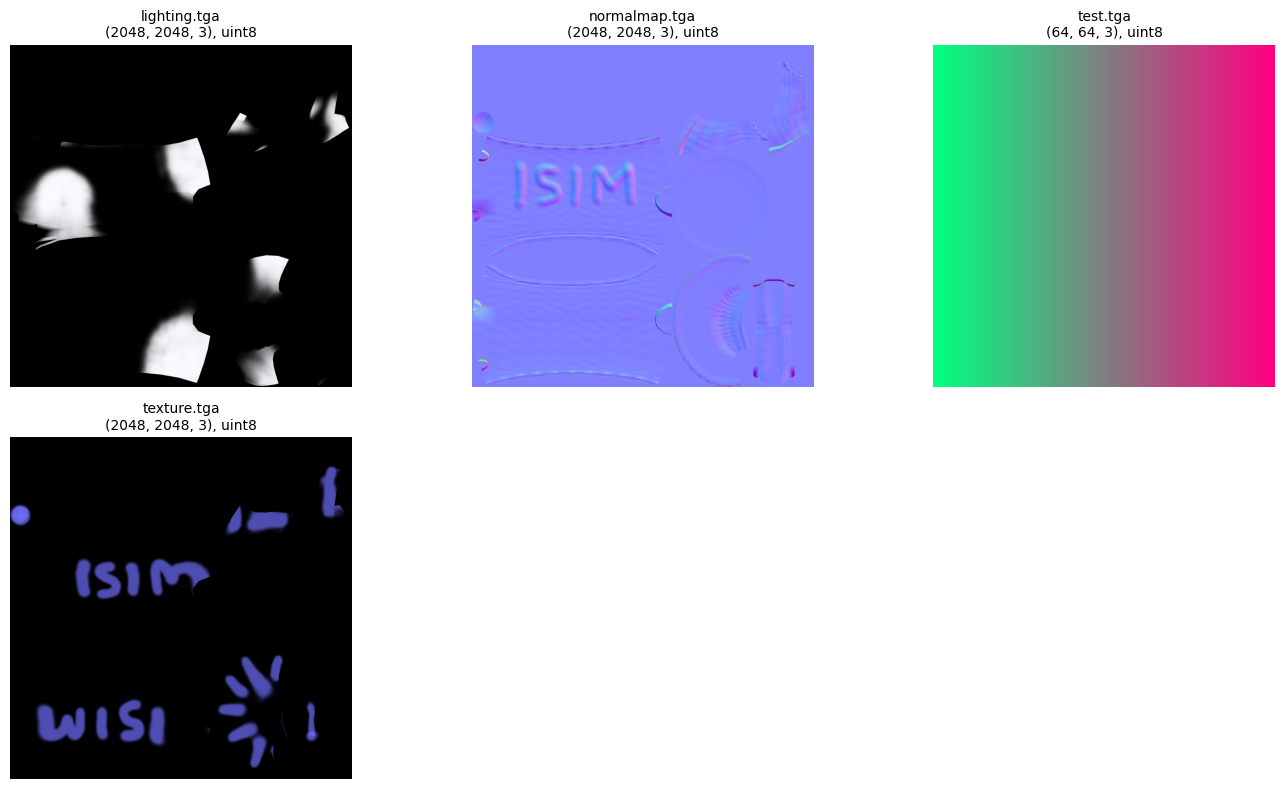


=== object_vbo.npz ===
Keys: ['vertices', 'normals_flat', 'normals_smooth', 'colors', 'uvs']
  vertices: shape=(4680, 3), dtype=float32
  normals_flat: shape=(4680, 3), dtype=float32
  normals_smooth: shape=(4680, 3), dtype=float32
  colors: shape=(4680, 3), dtype=float32
  uvs: shape=(4680, 2), dtype=float32


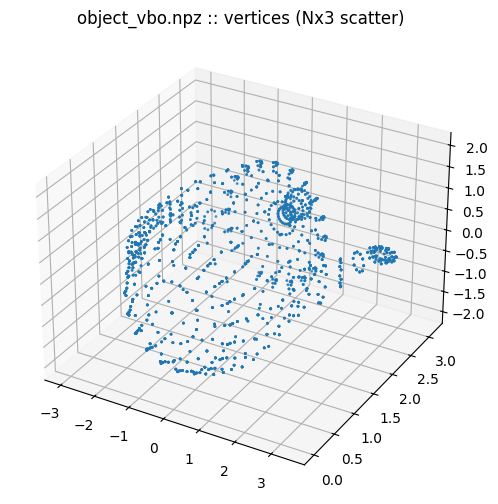

In [3]:
# TGA loading 
def load_tga(path):
    try:
        from PIL import Image
        img = Image.open(path)
        return np.array(img)
    except Exception:
        import imageio.v2 as imageio
        return imageio.imread(path)

def show_image_grid(images, titles, cols=3, figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        ax = plt.subplot(rows, cols, i)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
    plt.tight_layout()
    plt.show()

# NPZ visualizer prints keys and tries simple plots
def visualize_npz(path):
    data = np.load(path, allow_pickle=True)
    keys = list(data.keys())
    print(f"\n=== {os.path.basename(path)} ===")
    print("Keys:", keys)

    # Print shapes/dtypes
    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray):
            print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")
        else:
            print(f"  {k}: type={type(arr)}")


    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[1] in (2, 3) and arr.shape[0] >= 3:
            pts = arr.astype(float)
            if pts.shape[1] == 2:
                plt.figure(figsize=(6, 6))
                plt.scatter(pts[:, 0], pts[:, 1], s=1)
                plt.title(f"{os.path.basename(path)} :: {k} (Nx2 scatter)")
                plt.gca().set_aspect("equal", adjustable="box")
                plt.show()
            else:
                fig = plt.figure(figsize=(7, 6))
                ax = fig.add_subplot(111, projection="3d")
                ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1)
                ax.set_title(f"{os.path.basename(path)} :: {k} (Nx3 scatter)")
                plt.show()
            break


    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray) and arr.ndim in (2, 3):
            # Heuristic: big 2D/3D arrays might be image-like
            if arr.ndim == 2 and arr.shape[0] >= 16 and arr.shape[1] >= 16:
                plt.figure(figsize=(6, 6))
                plt.imshow(arr, cmap="gray")
                plt.title(f"{os.path.basename(path)} :: {k} (2D array)")
                plt.axis("off")
                plt.show()
                break
            if arr.ndim == 3 and arr.shape[0] >= 16 and arr.shape[1] >= 16 and arr.shape[2] in (1, 3, 4):
                plt.figure(figsize=(6, 6))
                plt.imshow(arr)
                plt.title(f"{os.path.basename(path)} :: {k} (3D array)")
                plt.axis("off")
                plt.show()
                break


folder = "."  
files = sorted([f for f in os.listdir(folder) if not f.lower().endswith(".ipynb")])

tga_files = [f for f in files if f.lower().endswith(".tga")]
npz_files = [f for f in files if f.lower().endswith(".npz")]

# Visualizing all .tga in a grid
if tga_files:
    imgs, titles = [], []
    for f in tga_files:
        p = os.path.join(folder, f)
        img = load_tga(p)
        imgs.append(img)
        titles.append(f"{f}\n{img.shape}, {img.dtype}")
    show_image_grid(imgs, titles, cols=3)

# Visualizing all .npz (prints keys and  plots)
for f in npz_files:
    visualize_npz(os.path.join(folder, f))


## 2. The color and 3. The normal vectors

In [4]:
#importing
from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math
import sys

In [5]:
d = np.load("object_vbo.npz")
vertices = d["vertices"].astype(np.float32)
colors   = d["colors"].astype(np.float32)

# keep these (not used in Color-part shaders, but you have them)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

print(vertices.shape, colors.shape)

(4680, 3) (4680, 3)


In [6]:
# helpers functions i will be needed
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)

    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)

    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f

    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    # column-major for OpenGL
    return M.T  


# shaders

def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

VS_BASE = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

out vec3 vCol;
void main() {
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_VBO_SMOOTH = """
#version 330 core
in vec3 vCol;
out vec4 outColor;
void main() { outColor = vec4(vCol, 1.0); }
"""

VS_FLAT = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

flat out vec3 vCol;          // disable interpolation
void main() {
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_VBO_FLAT = """
#version 330 core
flat in vec3 vCol;
out vec4 outColor;
void main() { outColor = vec4(vCol, 1.0); }
"""

# "yellow" mode for task 2.1 image 
VS_YELLOW = """
#version 330 core
layout(location=0) in vec3 in_pos;
uniform mat4 uMVP;
void main() { gl_Position = uMVP * vec4(in_pos, 1.0); }
"""
FS_YELLOW = """
#version 330 core
out vec4 outColor;
void main() { outColor = vec4(1.0, 1.0, 0.0, 1.0); }
"""


# global

# Interaction parameters 
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

vao = None
vbo_pos = None
vbo_col = None

prog_yellow = None
prog_smooth = None
prog_flat = None
current_prog = None

def mode_21_smooth_yellow():
    global current_prog
    current_prog = prog_yellow
    print("[MODE] 2.1 smooth (yellow)")

def mode_22_colored_pot():
    global current_prog
    current_prog = prog_smooth
    print("[MODE] 2.2 colored (VBO color, smooth interpolation)")

def mode_23_triangle_color():
    global current_prog
    current_prog = prog_flat
    print("[MODE] 2.3 triangle colors (flat / no interpolation)")

def init_gl():
    global vao, vbo_pos, vbo_col, prog_yellow, prog_smooth, prog_flat, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)  
    glEnable(GL_DEPTH_TEST)

    prog_yellow = link_program(VS_YELLOW, FS_YELLOW)
    prog_smooth = link_program(VS_BASE, FS_VBO_SMOOTH)
    prog_flat   = link_program(VS_FLAT, FS_VBO_FLAT)

    current_prog = prog_smooth

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions @ location 0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # colors @ location 1
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Press 1 (yellow), 2 (VBO smooth), 3 (VBO flat)")


# display

def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:  # scroll up
        distance = max(1.0, distance - 0.3)
    elif button == 4:  # scroll down
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    if key in (b'q', b'\x1b'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_21_smooth_yellow()
    elif key == b'2':
        mode_22_colored_pot()
    elif key == b'3':
        mode_23_triangle_color()


In [7]:
VS_LIGHT = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec3 vN;
out vec3 vPosW;

void main(){
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;

    // OK because uModel = rotation only in our viewer
    vN = mat3(uModel) * in_nrm;

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_LIGHT_BLUE = """
#version 330 core
in vec3 vN;
in vec3 vPosW;

out vec4 outColor;

uniform vec3 uLightPosW;
uniform vec3 uBaseColor; // blue

void main(){
    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);

    float diff = max(dot(N, L), 0.0);

    // ambient + diffuse
    vec3 color = uBaseColor * (0.20 + 0.80 * diff);

    outColor = vec4(color, 1.0);
}
"""


# Add new globals 
vbo_nrm_flat = None
vbo_nrm_smooth = None

# same program for both I just swap normal buffer
prog_light = None  

def init_gl():
    global vao, vbo_pos, vbo_col, vbo_nrm_flat, vbo_nrm_smooth
    global prog_yellow, prog_smooth, prog_flat, prog_light, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    
    prog_yellow = link_program(VS_YELLOW, FS_YELLOW)
    prog_smooth = link_program(VS_BASE, FS_VBO_SMOOTH)
    prog_flat   = link_program(VS_FLAT, FS_VBO_FLAT)

    
    prog_light  = link_program(VS_LIGHT, FS_LIGHT_BLUE)

    # default
    current_prog = prog_smooth

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions @ location 0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # colors @ location 1 
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)

    # normals flat @ location 1 
    vbo_nrm_flat = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_flat)
    glBufferData(GL_ARRAY_BUFFER, normals_flat.nbytes, normals_flat, GL_STATIC_DRAW)

    # normals smooth @ location 1 
    vbo_nrm_smooth = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_smooth)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)

    # I will enable attrib 1 and point it to either colors or normals depending on mode.
    glEnableVertexAttribArray(1)

    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("Keys: 4=3.1 flat-lit blue, 5=3.2 smooth-lit blue (1/2/3 )")


def mode_31_flat_lighting_blue():
    global current_prog
    current_prog = prog_light

    glBindVertexArray(vao)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_flat)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)
    glBindVertexArray(0)

    print("3.1 Flat lighting (blue) using normals_flat")

def mode_32_smooth_lighting_blue():
    global current_prog
    current_prog = prog_light

    glBindVertexArray(vao)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_smooth)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)
    glBindVertexArray(0)

    print("3.2 Smooth lighting (blue) using normals_smooth")



def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # uMVP exists in all our programs
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    # For lighting program only uModel, uLightPosW, uBaseColor
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)

    locC = glGetUniformLocation(current_prog, "uBaseColor")
    if locC != -1:
        glUniform3f(locC, 0.0, 0.0, 1.0)  # blue

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glUseProgram(0)
    glutSwapBuffers()


def keyboard(key, x, y):
    if key in (b'q', b'\x1b'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    # existing modes 
    if key == b'1':
        mode_21_smooth_yellow()
    elif key == b'2':
        mode_22_colored_pot()
    elif key == b'3':
        mode_23_triangle_color()

    # new lighting modes
    elif key == b'4':
        mode_31_flat_lighting_blue()
    elif key == b'5':
        mode_32_smooth_lighting_blue()


In [ ]:
# now the viewer

def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP Color Part (2.1/2.2/2.3)")

    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)

    glutMainLoop()

run_viewer()

Keys: 4=3.1 flat-lit blue, 5=3.2 smooth-lit blue (1/2/3 )
[MODE] 2.1 smooth (yellow)
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.3 triangle colors (flat / no interpolation)
3.1 Flat lighting (blue) using normals_flat
3.2 Smooth lighting (blue) using normals_smooth
3.1 Flat lighting (blue) using normals_flat
[MODE] 2.3 triangle colors (flat / no interpolation)
3.1 Flat lighting (blue) using normals_flat
3.2 Smooth lighting (blue) using normals_smooth
[MODE] 2.3 triangle colors (flat / no interpolation)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.3 triangle colors (flat / no interpolation)
3.1 Flat lighting (blue) using normals_flat
3.2 Smooth lighting (blue) using normals_smooth
[MODE] 2.1 smooth (yellow)
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.2

### Outputs I got:

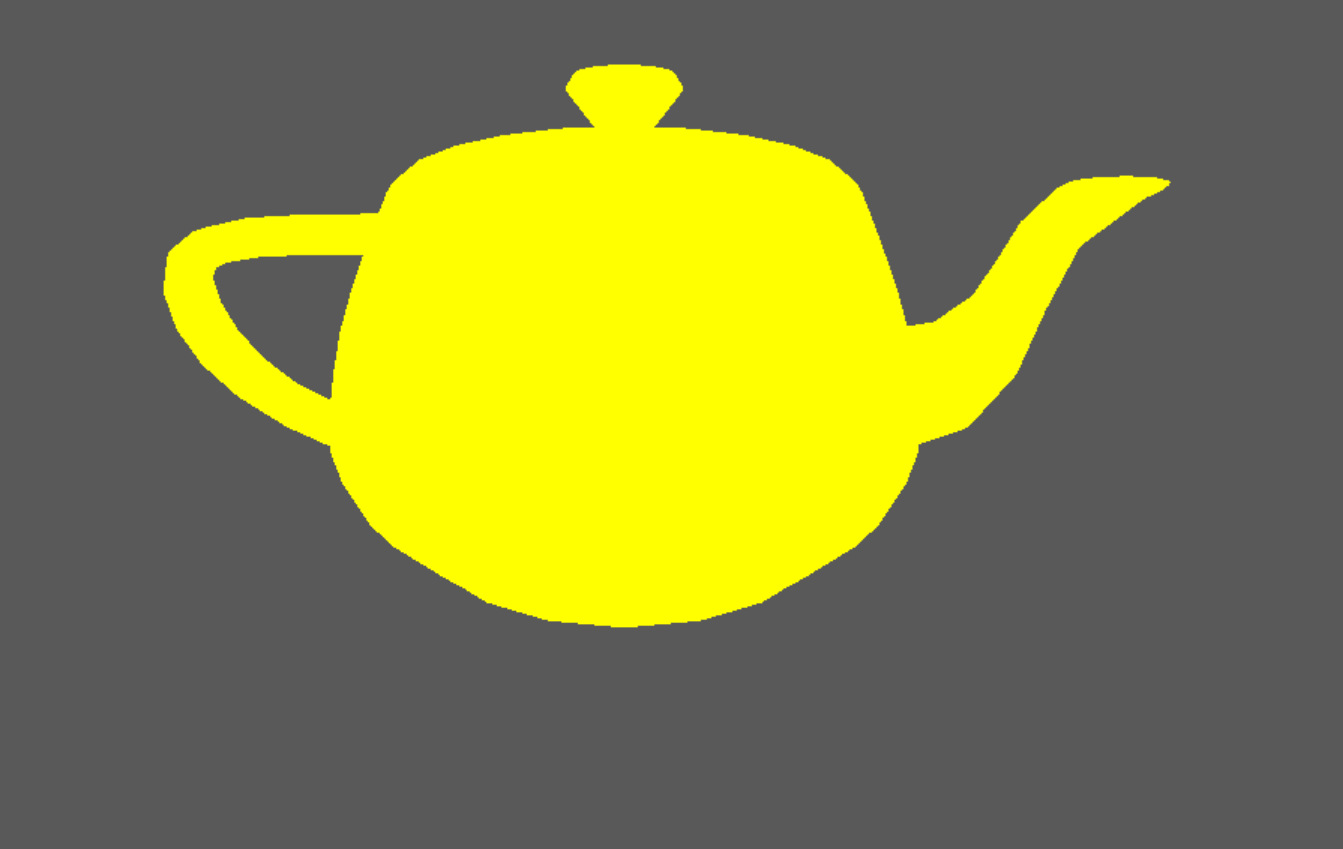

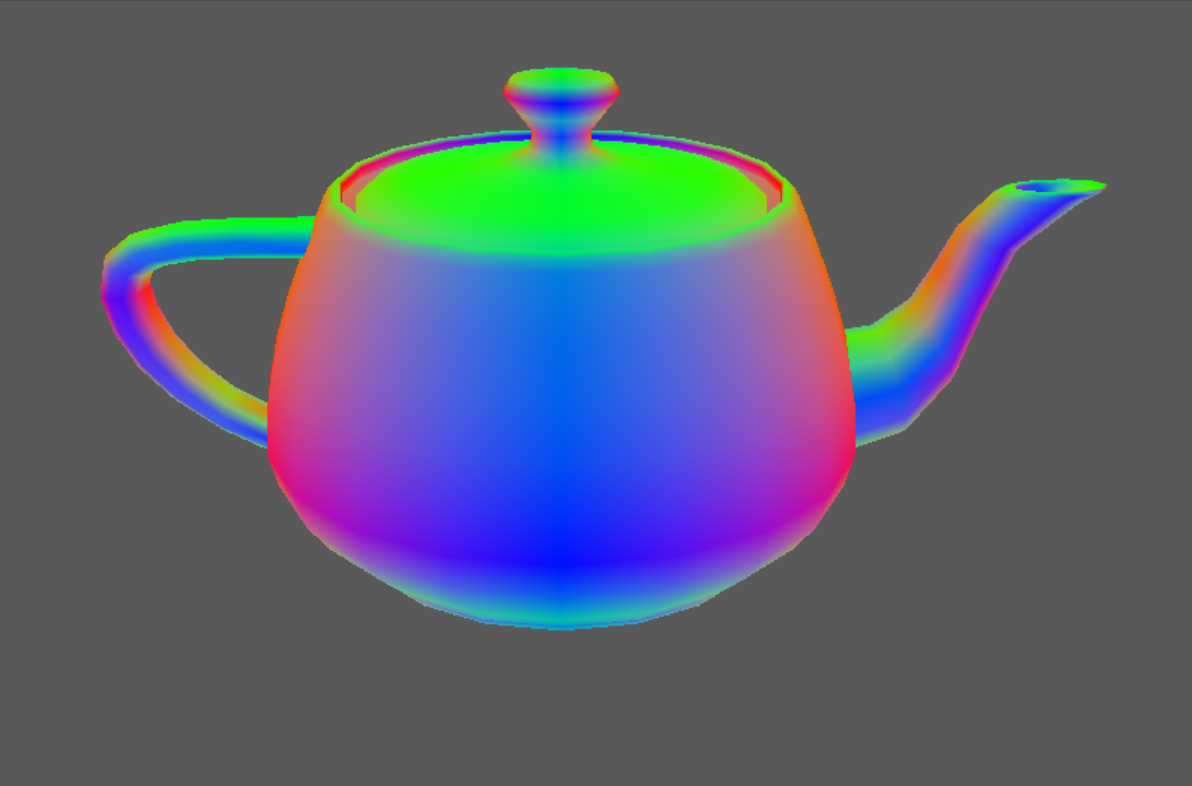

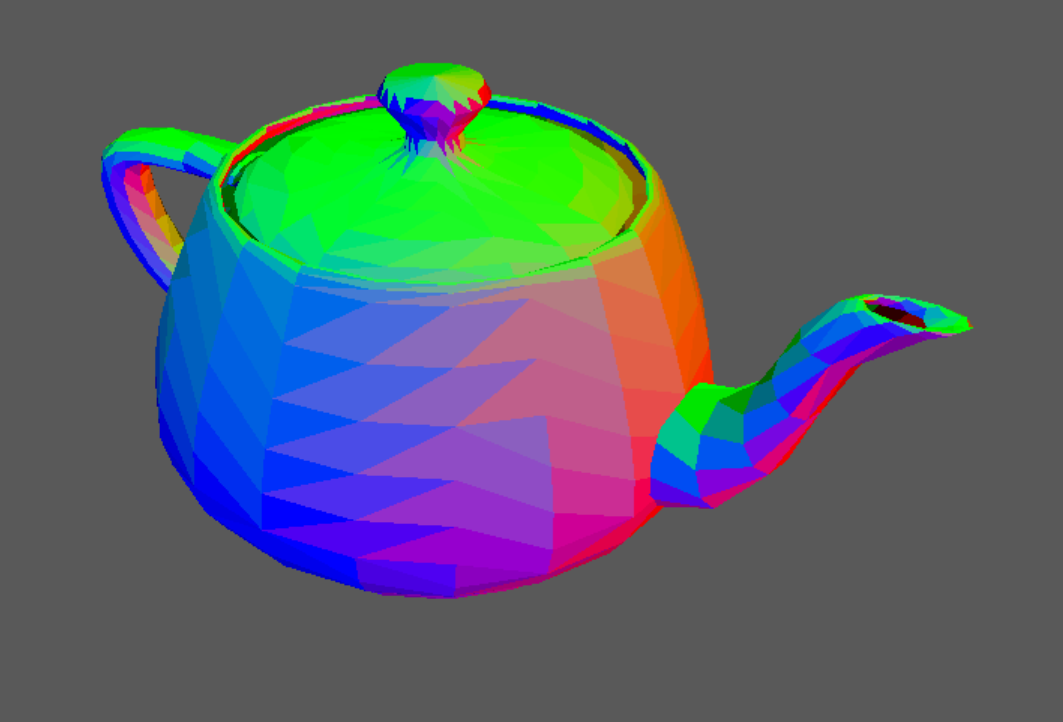

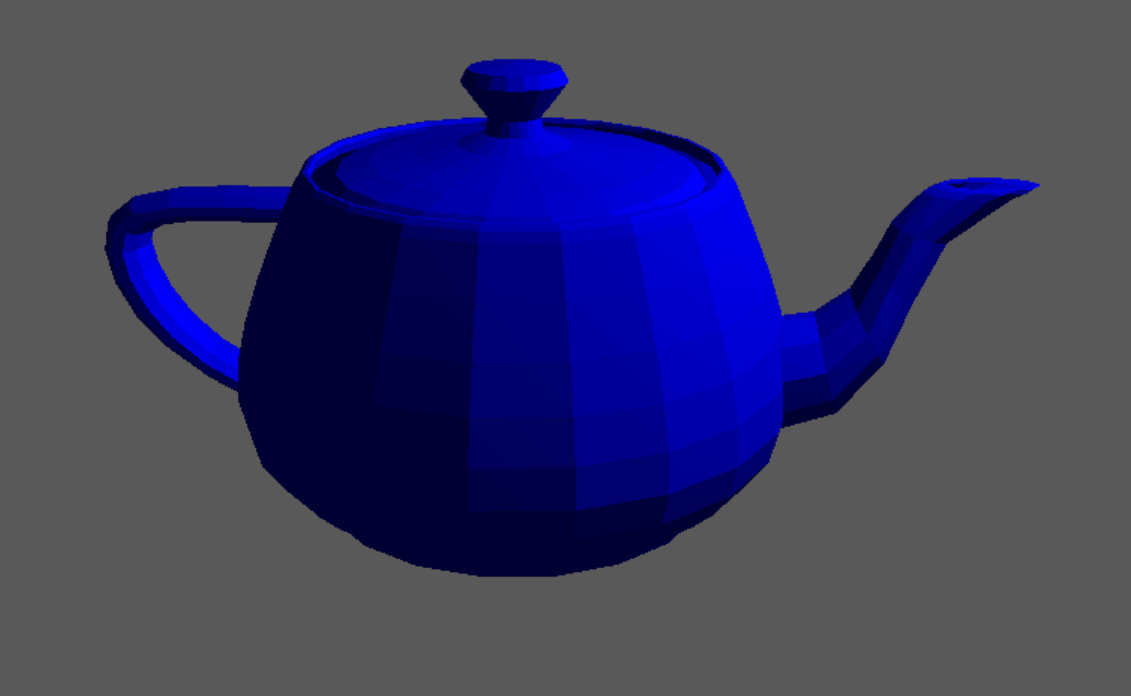

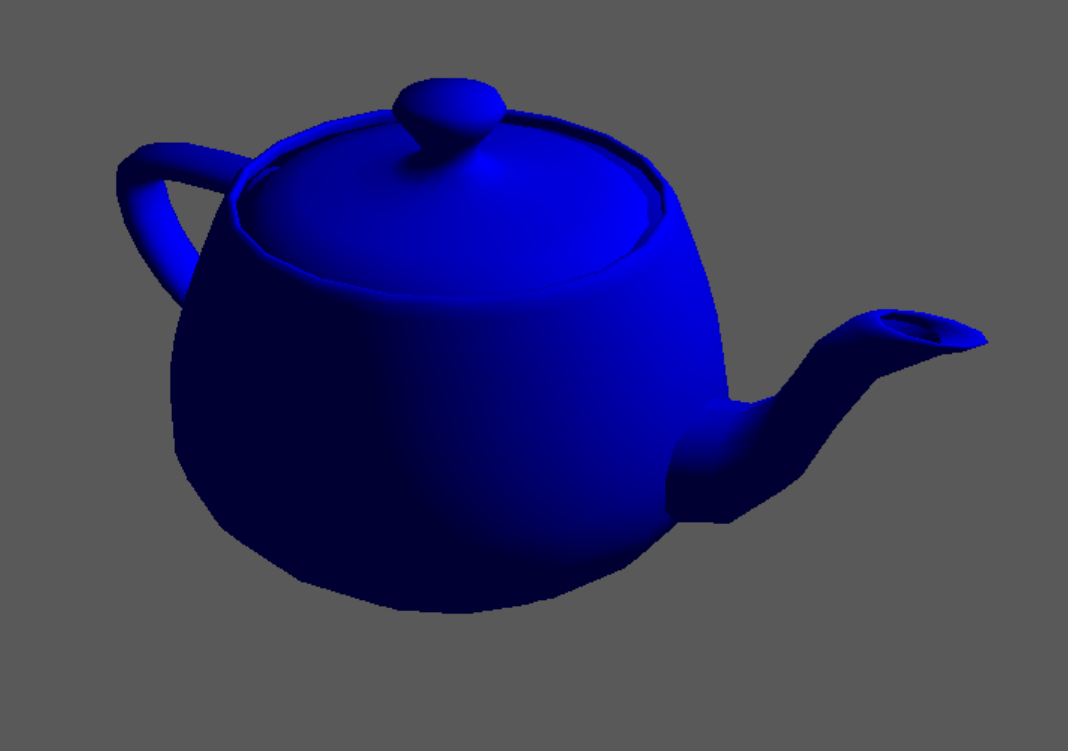

## 4. The textures

In [ ]:
from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

OBJECT_TEX_PATH = "texture.tga"

# first I'm loading the mesh data 
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)


def load_image_rgba(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr, np.full_like(arr, 255)], axis=-1)
        elif arr.shape[2] == 3:
            alpha = np.full((arr.shape[0], arr.shape[1], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        pass
    return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        obj_img = None
else:
    print(f"[WARN] Texture file '{OBJECT_TEX_PATH}' not found.")

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print(f"[INFO] Using generated checker texture ({ow}x{oh}).")

# Now setting the interaction parameters 
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1
swap_uv = 0

# Spotlight params 
spot_center   = [0.8, 0.4]  
spot_radius   = 1          
spot_strength = 3.5           
spot_power    = 2.5           

# GL objects 
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
tex_object = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None


def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# Shader helpers functions
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

#  Shaders 
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

UV_FIX = """
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;
vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}
"""


FS_TEX = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
{UV_FIX}
void main(){{
    outColor = texture(uTex, fixUV(vUV));
}}
"""


FS_TEX_LIGHT = f"""
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;
{UV_FIX}

void main(){{
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    vec3 lit = albedo * (0.10 + 0.90 * diff);
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}}
"""


FS_SPOT = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;

uniform vec2  uResolution;
uniform vec2  uSpotCenterNDC;
uniform float uSpotRadius;
uniform float uSpotStrength;
uniform float uSpotPower;

{UV_FIX}

void main(){{
    vec3 base = texture(uTex, fixUV(vUV)).rgb;

    vec2 frag = gl_FragCoord.xy / uResolution;
    float d = distance(frag, uSpotCenterNDC);

    float m = smoothstep(uSpotRadius, 0.0, d);
    m = pow(m, uSpotPower);   // <<< sharper edge

    vec3 outc = base * (1.0 + uSpotStrength * m);
    outColor = vec4(outc, 1.0);
}}
"""

# Texture upload 
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

#  Modes 
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print(" UV coloring")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("Texture only")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("Texture + lighting")

def mode_44_spotlight_screen():
    global current_prog
    current_prog = prog_spot
    print("Spotlight (screen-space projection)")

#  Init GL 
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT)

    tex_object = create_texture_rgba(obj_img, ow, oh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex
    print("Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1: glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1: glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1: glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1: glUniform1i(loc, swap_uv)

# Display
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    set_uv_uniforms(current_prog)

    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    
    locRes = glGetUniformLocation(current_prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))
    locCenter = glGetUniformLocation(current_prog, "uSpotCenterNDC")
    if locCenter != -1:
        glUniform2f(locCenter, spot_center[0], spot_center[1])
    locRad = glGetUniformLocation(current_prog, "uSpotRadius")
    if locRad != -1:
        glUniform1f(locRad, float(spot_radius))
    locStr = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStr != -1:
        glUniform1f(locStr, float(spot_strength))
    locPow = glGetUniformLocation(current_prog, "uSpotPower")
    if locPow != -1:
        glUniform1f(locPow, float(spot_power))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# Interaction 
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1': mode_41_uv_coloring()
    elif key == b'2': mode_42_texture_only()
    elif key == b'3': mode_43_texture_plus_lighting()
    elif key == b'4': mode_44_spotlight_screen()
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset")

# testing
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - smaller spotlight")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()


[INFO] Loaded object texture: texture.tga (2048x2048)
Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[MODE] 4.3 Texture + lighting
[MODE] 4.4 Spotlight (screen-space projection)


## The outputs I got:

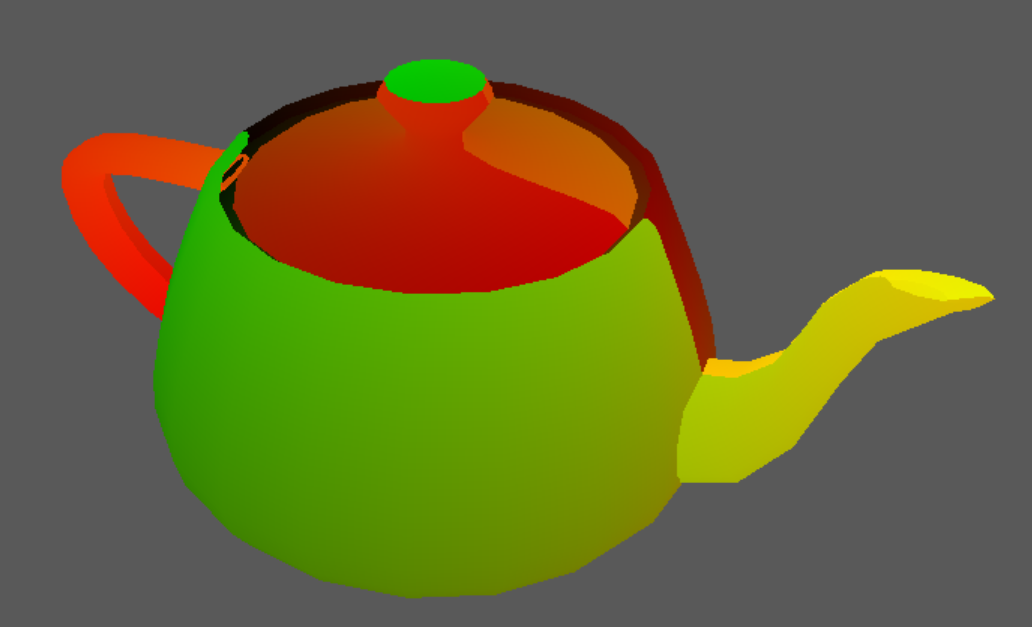

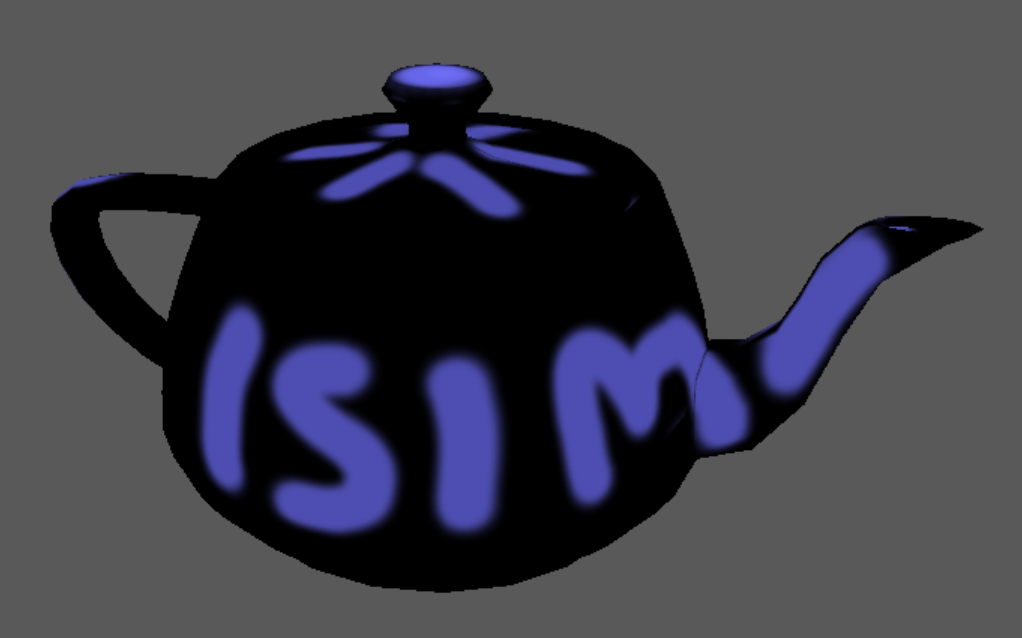

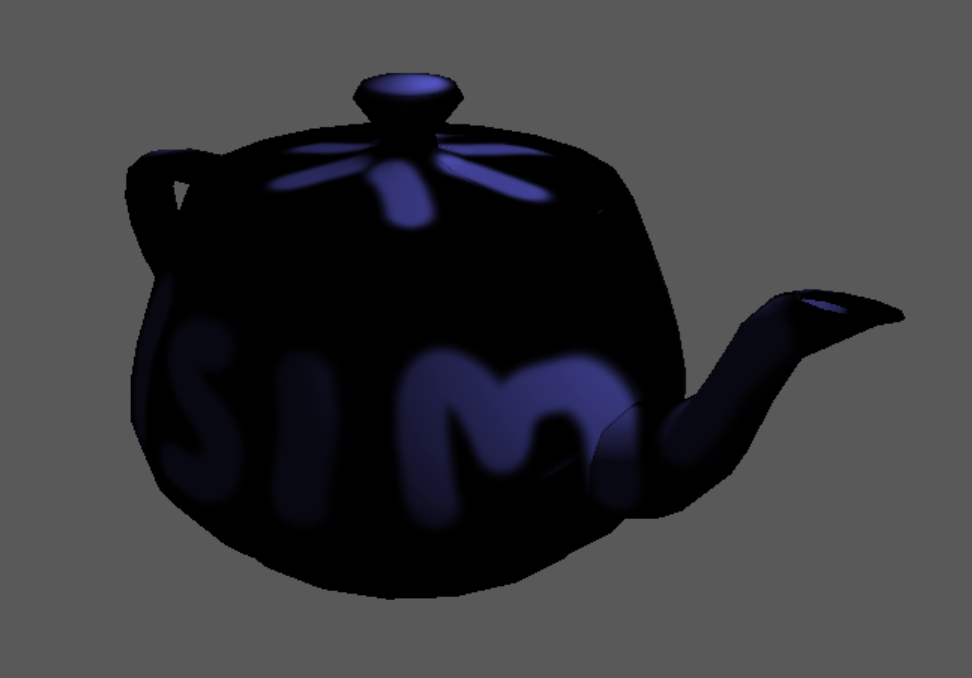

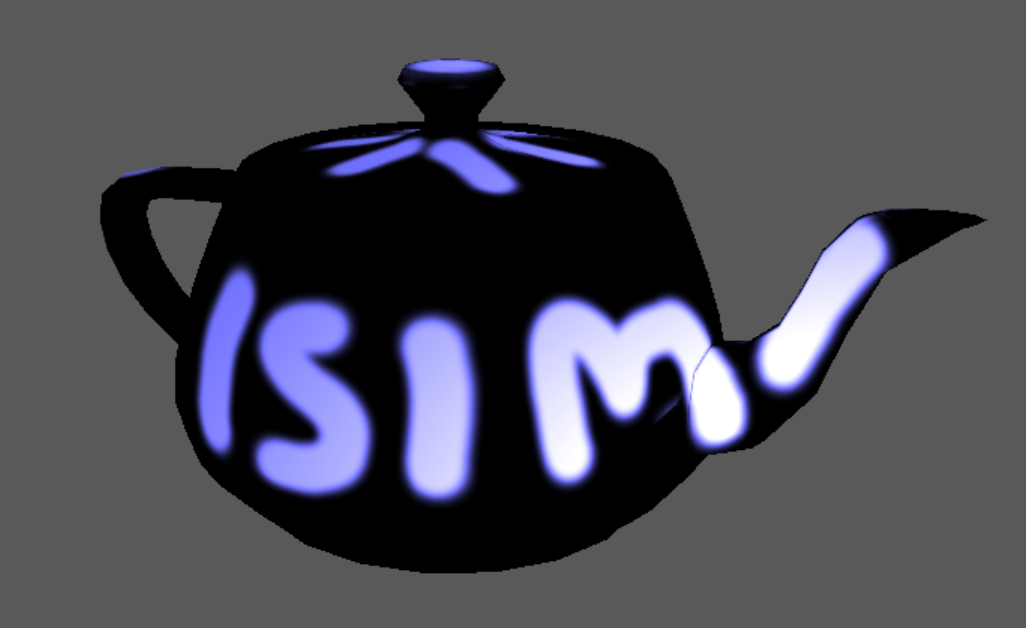

## 5. Multiple effects

In [ ]:
from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os


# Loading the given mesh

d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)
colors         = d["colors"].astype(np.float32)


# Compute tangents for TBN
def compute_tangents(verts, norms, tex):
    n = verts.shape[0]
    assert n % 3 == 0, "Vertex count must be multiple of 3 for triangles."
    tan = np.zeros((n, 3), dtype=np.float32)
    bit = np.zeros((n, 3), dtype=np.float32)

    for i in range(0, n, 3):
        p0, p1, p2 = verts[i+0], verts[i+1], verts[i+2]
        uv0, uv1, uv2 = tex[i+0], tex[i+1], tex[i+2]

        e1 = p1 - p0
        e2 = p2 - p0
        duv1 = uv1 - uv0
        duv2 = uv2 - uv0

        denom = duv1[0]*duv2[1] - duv1[1]*duv2[0]
        if abs(denom) < 1e-8:
            continue
        r = 1.0 / denom

        t = (e1 * duv2[1] - e2 * duv1[1]) * r
        b = (e2 * duv1[0] - e1 * duv2[0]) * r

        tan[i+0] += t; tan[i+1] += t; tan[i+2] += t
        bit[i+0] += b; bit[i+1] += b; bit[i+2] += b

    T = np.zeros((n, 4), dtype=np.float32)  # xyz + handedness
    for i in range(n):
        N = norms[i]
        t = tan[i]
        t = t - N * np.dot(N, t)
        tl = np.linalg.norm(t)
        if tl < 1e-8:
            t = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            tl = 1.0
        t = t / tl

        b = bit[i]
        sign = 1.0
        if np.dot(np.cross(N, t), b) < 0.0:
            sign = -1.0

        T[i, :3] = t
        T[i,  3] = sign
    return T

tangents4 = compute_tangents(vertices, normals_smooth, uvs)


# Normal map loading 
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("No normal map ")
else:
    print(f"Loaded normal map: {nm_path} ({nw}x{nh})")


# Interaction
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1


# GL handles
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
vbo_col = None
vbo_tan = None
tex_normal = None
programs = {}


# Matrices
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T


# Shader helpers
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog


# GLSL
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;
layout(location=3) in vec3 in_col;
layout(location=4) in vec4 in_tan;

uniform mat4 uMVP;
uniform mat4 uModel;
uniform mat4 uView;

out vec3 vN;
out vec2 vUV;
out vec3 vCol;
out float vViewZ;
out vec3 vT;
out float vTSign;

void main(){
    vN = mat3(uModel) * in_nrm;
    vT = mat3(uModel) * in_tan.xyz;
    vTSign = in_tan.w;

    vUV = in_uv;
    vCol = in_col;

    vec4 posV = uView * vec4(in_pos, 1.0);
    vViewZ = -posV.z;

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
in vec3 vCol;
in float vViewZ;
in vec3 vT;
in float vTSign;

out vec4 outColor;

uniform vec3 uLightDirW;
uniform vec2 uResolution;
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

vec3 baseColor(){ return clamp(vCol, 0.0, 1.0); }

vec3 litColor(vec3 N){
    vec3 base = baseColor();
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.35 + 0.65 * diff);
}

vec2 uvFix(vec2 uv){
    return vec2(uv.x, 1.0 - uv.y);
}
"""

FS_51 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

FS_52 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    float scan = 0.70 + 0.30 * sin(gl_FragCoord.y * 1.20);
    float val = g * scan;
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

FS_53 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    float z = gl_FragCoord.z;
    float b = clamp(1.0 - z, 0.0, 1.0);
    float val = g * (0.45 + 0.55 * b);
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

FS_54 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float fogNear = 4.0;
    float fogFar  = 12.0;
    float fog = clamp((vViewZ - fogNear) / (fogFar - fogNear), 0.0, 1.0);
    vec3 fogColor = vec3(0.40);
    vec3 outc = mix(lit, fogColor, fog);
    outColor = vec4(outc, 1.0);
}
"""

#5.5 SCREEN-SPACE 6x6 squares separated by 2 pixels
# FS_55 = FS_HEADER + """
# void main(){
#     vec3 lit = litColor(vN);

#     float square = 6.0;
#     float gap    = 2.0;
#     float period = square + gap;

#     int ix = int(floor(gl_FragCoord.x / period));
#     int iy = int(floor(gl_FragCoord.y / period));

#     float mx = mod(gl_FragCoord.x, period);
#     float my = mod(gl_FragCoord.y, period);

#     bool inGap = (mx >= square) || (my >= square);
#     bool keep  = ((ix + iy) % 2) == 0;

#     if(inGap || !keep){
#         outColor = vec4(0.0, 0.0, 0.0, 1.0);
#         // outColor = vec4(0.40, 0.40, 0.40, 1.0);
#     }else{
#         outColor = vec4(lit, 1.0);
#     }
# }
# """

FS_55 = FS_HEADER + """
void main(){
    vec3 base = baseColor();   // from vCol

    float square = 6.0;        // 6px square
    float gap    = 2.0;        // 2px black line
    float period = square + gap;

    float mx = mod(gl_FragCoord.x, period);
    float my = mod(gl_FragCoord.y, period);

    bool inLine = (mx >= square) || (my >= square);

    if(inLine){
        outColor = vec4(0.0, 0.0, 0.0, 1.0);     // black grid lines
    }else{
        outColor = vec4(base, 1.0);              // keep full color (no dark shading)
    }
}
"""


FS_56 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);
    vec3 desat = mix(lit, gray, 0.55);
    vec3 outc  = mix(desat, vec3(1.0), 0.08);
    outColor = vec4(outc, 1.0);
}
"""

FS_57 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));
    float t = smoothstep(0.15, 0.55, r);

    vec3 outc = mix(lit, gray, t);
    outColor = vec4(outc, 1.0);
}
"""

FS_58 = FS_HEADER + """
void main(){
    vec3 N = normalize(vN);
    vec3 T = normalize(vT);
    vec3 B = normalize(cross(N, T)) * vTSign;
    mat3 TBN = mat3(T, B, N);

    vec2 uv = uvFix(vUV);
    vec3 nm = texture(uNormalMap, uv).rgb * 2.0 - 1.0;
    vec3 Np = normalize(TBN * nm);

    vec3 lit = litColor(Np);
    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}


# Texture upload
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex


# Init GL
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, vbo_col, vbo_tan, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(3)
    glVertexAttribPointer(3, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_tan = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_tan)
    glBufferData(GL_ARRAY_BUFFER, tangents4.nbytes, tangents4, GL_STATIC_DRAW)
    glEnableVertexAttribArray(4)
    glVertexAttribPointer(4, 4, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 screen-grid | 6 washed | 7 radial | 8 normalmap bump")
    print("ESC/q quit")


# Display
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    locV = glGetUniformLocation(prog, "uView")
    if locV != -1:
        glUniformMatrix4fv(locV, 1, GL_FALSE, to_gl_mat(V))

    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()


# Interaction
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"Q5.{mode}")
        return


# Run
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (VBO color base) 5.1..5.8 (5.5 screen-grid)")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()

Loaded normal map: normalmap.tga (2048x2048)
keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 screen-grid | 6 washed | 7 radial | 8 normalmap bump
ESC/q quit
Q5.1
Q5.2


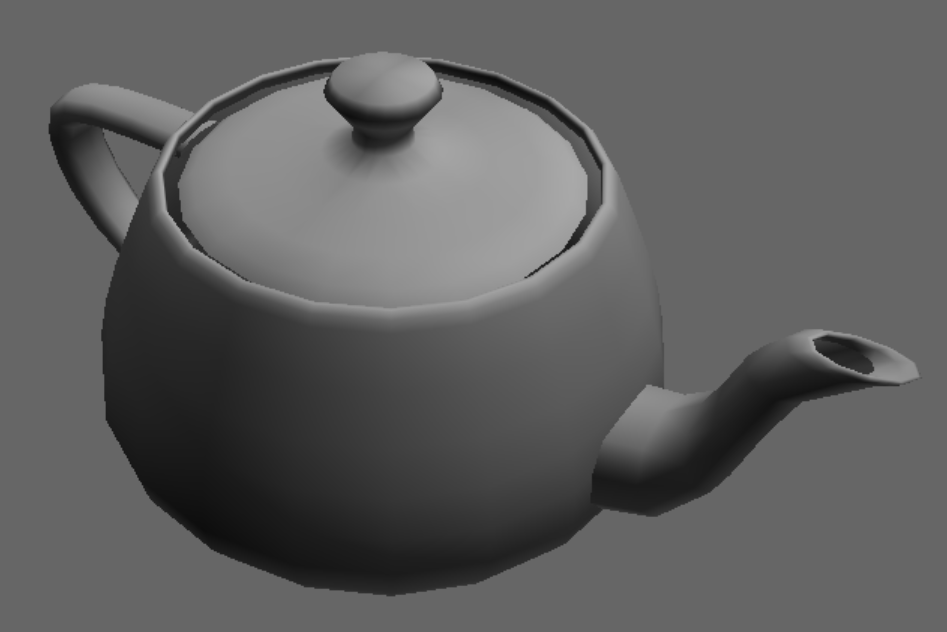

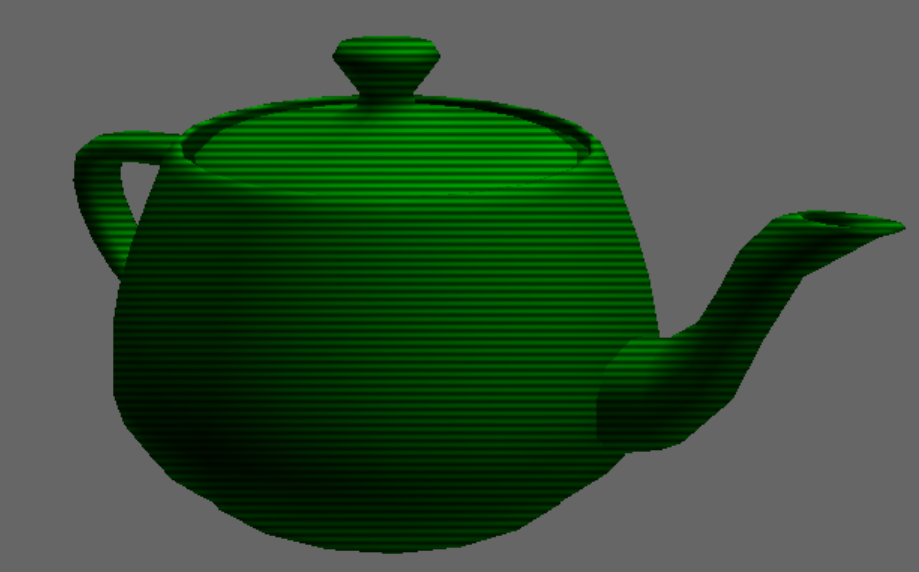

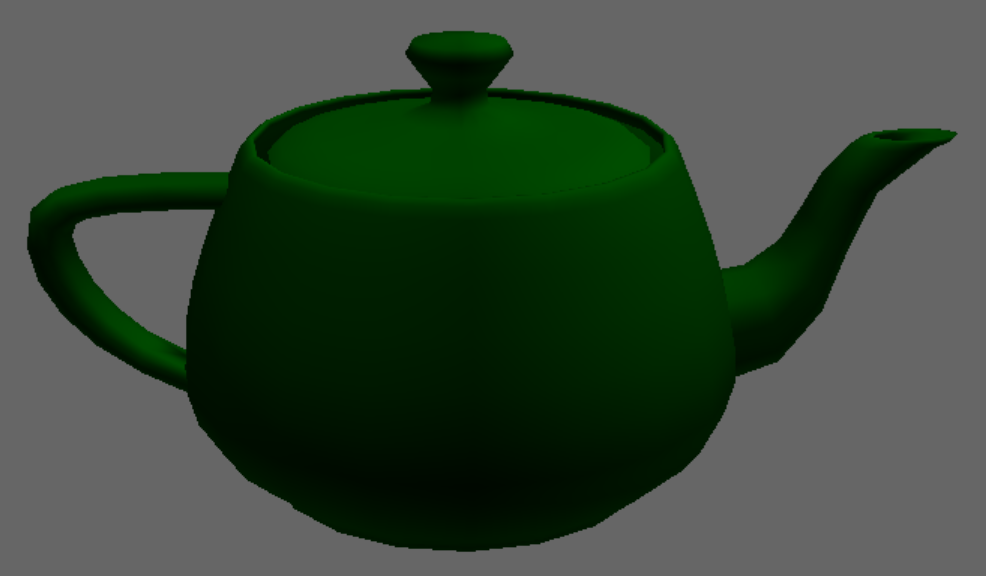

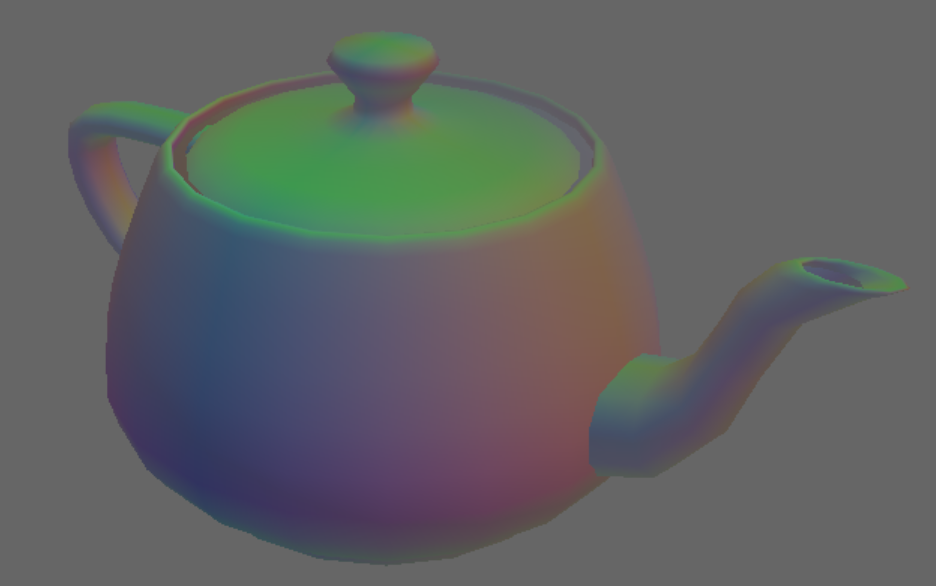

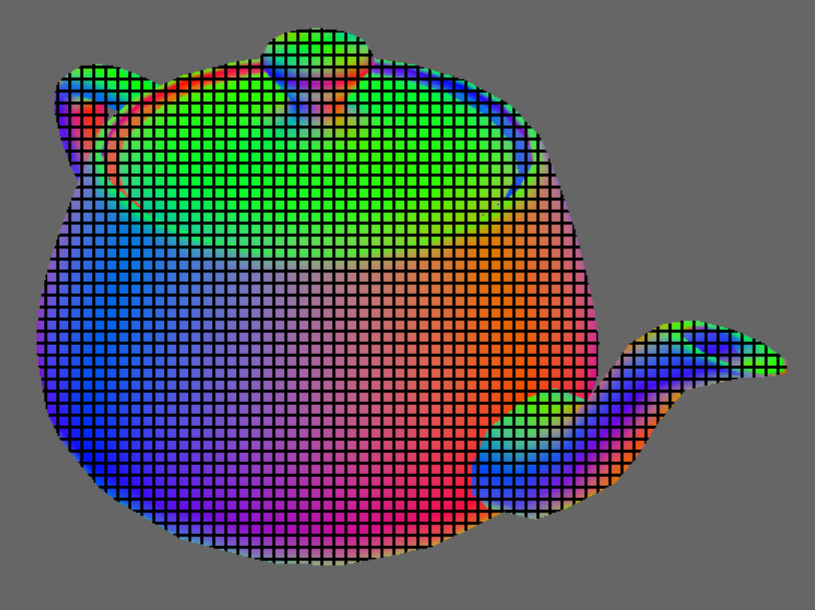

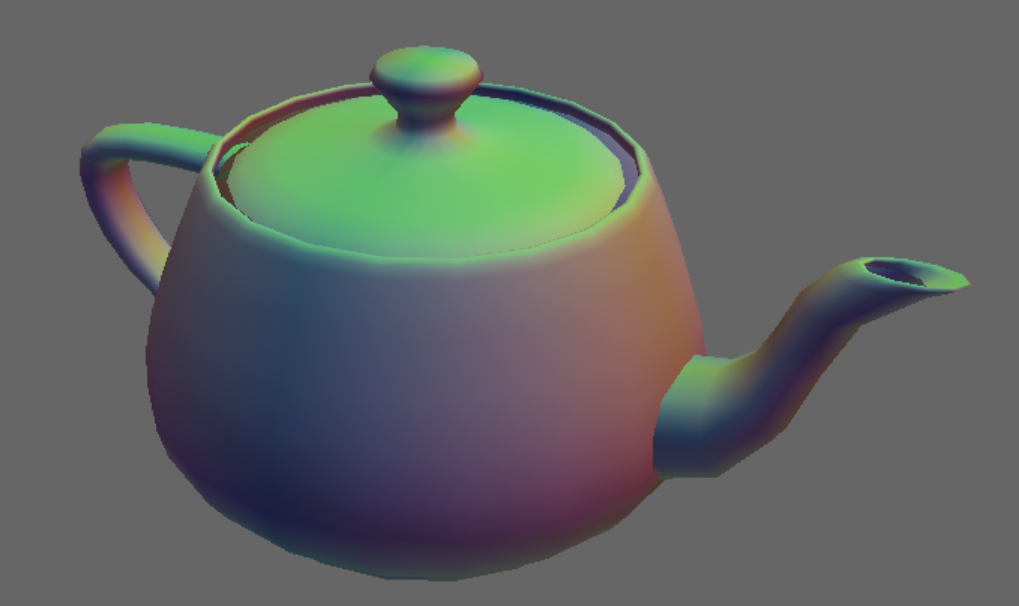

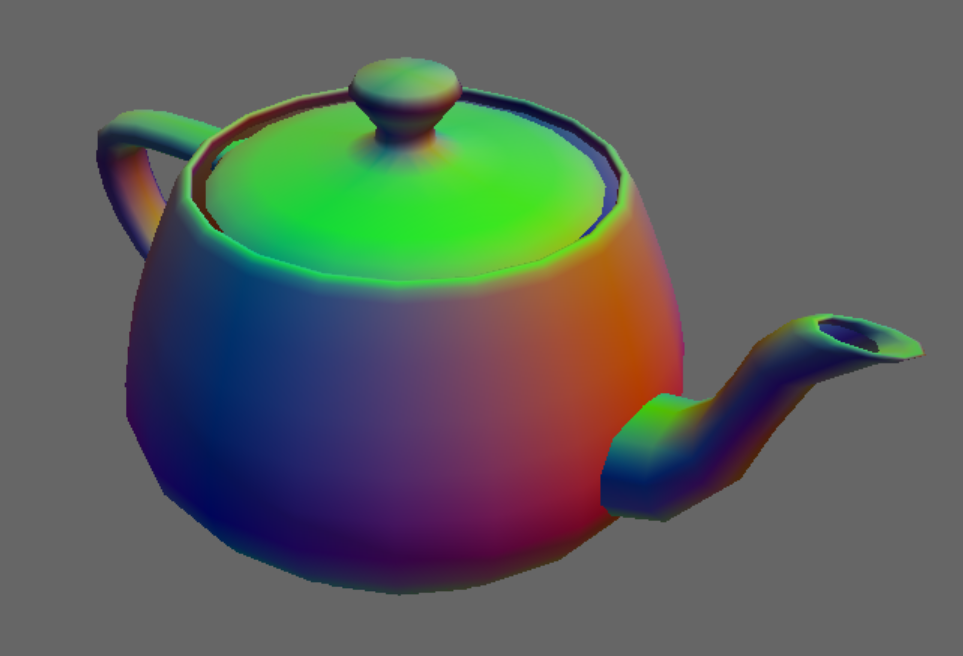

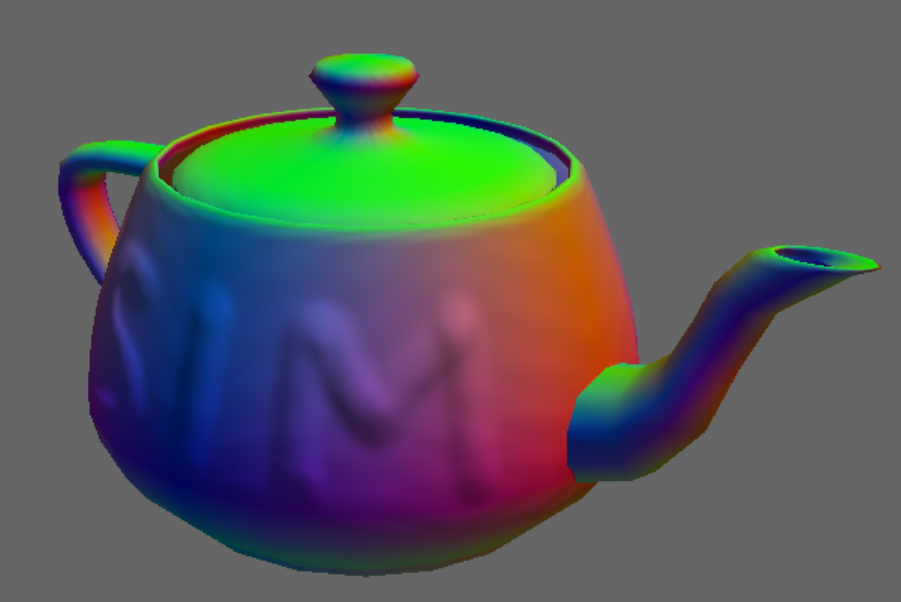

## Bonus
### Among all these images, one of them is wrong. Which one?

The wrong image is Question 5.8.

Because instead of using the normal map to modify the lighting, the normals are directly displayed as colors. Normals are directions, not colors, so this image is only a debug visualization and not a correct bump-mapped result.